# Imports and Settings

In [25]:
import pickle
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

# Select treshhold function

In [2]:
def select_threshold_by_tpr(
    y_true: np.ndarray, y_proba: np.ndarray, desired_tpr: float = 0.8
) -> Tuple[float, float, float]:
    """
    Подбирает порог классификации по заданному уровню полноты (True Positive Rate).

    Args:
        y_true : Истинные бинарные метки классов (0 или 1), shape (n_samples,).
        y_proba : Предсказанные вероятности положительного класса, shape (n_samples,).
        desired_tpr : Желаемый уровень TPR. По умолчанию 0.8.

    Returns:
        Tuple[float, float, float]: Кортеж из трех элементов:
            - threshold (float): Порог классификации, при котором TPR >= desired_tpr.
            - tpr (float): Достигнутый уровень TPR при этом пороге.
            - fpr (float): Частота ложноположительных срабатываний (FPR) при этом пороге.
    """
    # Вычисляем значения всех возможных порогов и FPR, TPR при них
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)

    # Находим индексы, где TPR >= desired_tpr
    candidates = np.where(tpr >= desired_tpr)[0]

    # Если желаемый TPR недостижим, выбираем индекс с максимальным TPR
    if len(candidates) == 0:
        idx = np.argmax(tpr)

    # Иначе берем минимальный порог, при котором TPR >= desired_tpr
    else:
        idx = candidates[0]

    # Возвращаем выбранный порог, TPR и FPR при этом пороге
    return thresholds[idx], tpr[idx], fpr[idx]

# Roc_curve

Для построения ROC кривой будем использовать данные обработанные итоговым пайплайном. 

In [41]:
df_test = pd.read_csv("../data/processed/transformed_test_2025-09-10-15-33.csv")
df_test.shape

(600000, 59)

In [42]:
# Загрузим датасет с целевой переменной
df_target = pd.read_csv("../data/target/train_target.csv")
df_target.shape

(3000000, 2)

In [43]:
# Разделим  таргет датасет на тренировочную и тестовую подвыборки
y_train, y_test = train_test_split(
    df_target, train_size=0.8, random_state=0, stratify=df_target.flag
)
y_train.shape, y_test.shape

((2400000, 2), (600000, 2))

In [44]:
# Отсортируем результат по id для согласованости с порядком тренировочных данных
y_train = y_train.sort_values(by="id").reset_index(drop=True)
y_test = y_test.sort_values(by="id").reset_index(drop=True)

In [45]:
X_test = df_test
y_test = y_test.flag
X_test.shape, y_test.shape

((600000, 59), (600000,))

In [46]:
# Загружаем веса моделей - их AUC на валидации
with open("../models/conservative_models_weights.pkl", "rb") as f:
    state = pickle.load(f)

val_auc_list = state["val_auc_list"]
val_auc_list

[0.7558470790046106,
 0.7541369034301536,
 0.7517121820944949,
 0.7529815101963229,
 0.7508019090111355,
 0.7530959167473436]

In [47]:
# Соберём словарь с моделями и их метриками
models_dict = {}
for i in range(5):
    model = CatBoostClassifier()
    model.load_model(f"../models/fold_{i}_conservative_model.bin")
    models_dict[f"fold_{i}_model"] = (model, val_auc_list[i])

model = CatBoostClassifier()
model.load_model("../models/full_data_conservative_model.bin")
models_dict["full_data_model"] = (model, val_auc_list[5])
models_dict

{'fold_0_model': (<catboost.core.CatBoostClassifier at 0x14508fc20>,
  0.7558470790046106),
 'fold_1_model': (<catboost.core.CatBoostClassifier at 0x1450909b0>,
  0.7541369034301536),
 'fold_2_model': (<catboost.core.CatBoostClassifier at 0x14508cdd0>,
  0.7517121820944949),
 'fold_3_model': (<catboost.core.CatBoostClassifier at 0x14508b380>,
  0.7529815101963229),
 'fold_4_model': (<catboost.core.CatBoostClassifier at 0x145099c10>,
  0.7508019090111355),
 'full_data_model': (<catboost.core.CatBoostClassifier at 0x14508ae70>,
  0.7530959167473436)}

In [48]:
"""
Собираем средневзвешенный по AUC предикт вероятностей классов 
на всех моделях фолдов и финальной моделе.
"""

df_pred = pd.DataFrame()

# Для каждой модели из словаря models_dict
for model_name, value in models_dict.items():
    # Получаем вероятности положительного класса на тестовой выборке
    pred = value[0].predict_proba(X_test)[:, 1]
    # Умножаем предсказания на вес модели (AUC на валидации или средний AUC)
    pred_coef = pred * value[1]
    # Сохраняем взвешенные предсказания в DataFrame
    df_pred[model_name] = pred_coef

# Суммируем веса всех моделей
weights_sum = sum(val[1] for val in models_dict.values())
# Формируем итоговое взвешенное среднее предсказание ансамбля
df_pred["ensemble_weighted_pred"] = df_pred.sum(axis=1) / weights_sum
# Получаем AUC ансамбля на тесте
auc = roc_auc_score(y_test, df_pred["ensemble_weighted_pred"])
print("AUC ensemble weighted test", auc)

AUC ensemble weighted test 0.7556367055597201


In [49]:
df_pred

,fold_0_model,fold_1_model,fold_2_model,fold_3_model,fold_4_model,full_data_model,ensemble_weighted_pred
0,0.286470,0.295670,0.276831,0.290294,0.270364,0.288667,0.378061
1,0.436678,0.434124,0.440150,0.423432,0.435253,0.443204,0.578244
2,0.367901,0.374043,0.374519,0.369469,0.383501,0.368701,0.495319
3,0.259156,0.231195,0.268520,0.258591,0.193966,0.241071,0.321451
4,0.408024,0.414891,0.396717,0.426037,0.402880,0.403383,0.542634
...,...,...,...,...,...,...,...
599995,0.343128,0.346676,0.339345,0.342140,0.327562,0.336701,0.450485
599996,0.252967,0.253245,0.256740,0.248248,0.269498,0.267769,0.342689
599997,0.074728,0.085390,0.072492,0.077110,0.082276,0.078005,0.104015
599998,0.408664,0.395901,0.381349,0.402520,0.396576,0.402046,0.528276


Итоговые предсказанные вероятности не выглядят как простое среднее по предсказаниям моделей, потому что предсказания умножаются на веса моделей (примерно 0.75), что уменьшает их значения. Однако деление суммы взвешенных предсказаний на сумму весов восстанавливает правильный масштаб  итоговых вероятностей.

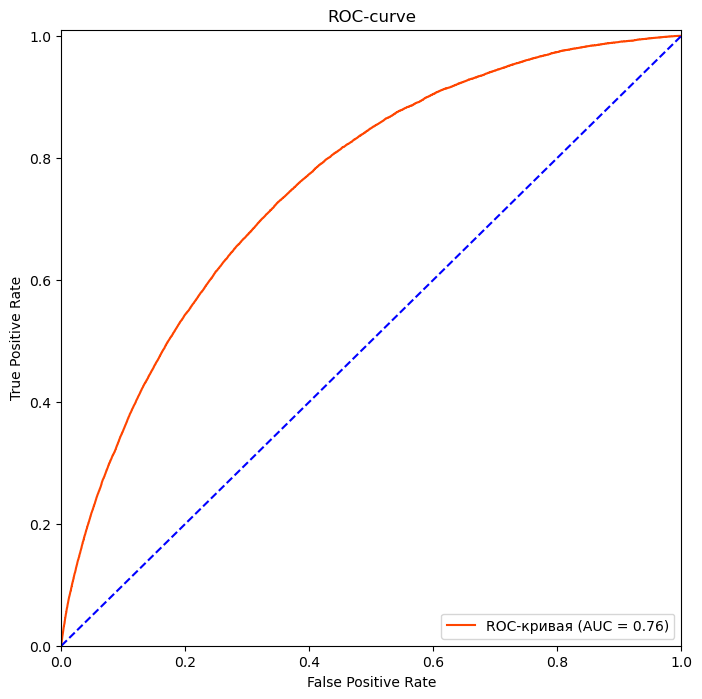

In [50]:
"""
Для каждого возможного порога классификации вычислим значения 
False Positive Rate (доля отрицательных примеров, ошибочно классифицированных как положительные)
True Positive Rate (доля истинноположительных среди всех положительных)
и соответствующие пороги.
"""
fpr, tpr, thresholds = roc_curve(y_test, df_pred["ensemble_weighted_pred"])

plt.figure(figsize=(8, 8))

# Построим график ROC-curve
plt.plot(fpr, tpr, color="orangered", label=f"ROC-кривая (AUC = {auc:.2f})")
# Добавим центральная диагональная линию для наглядности
plt.plot([0, 1], [0, 1], color="blue", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-curve")
plt.legend(loc="lower right")
plt.show()

# Optimal Thresholds selection

Найдём лучший порог классификации при котором разница между    
TPR и FPR будет максимальна.    
Эта разница отражает, насколько модель хорошо отделяет    
положительные примеры от отрицательных при данном пороге.   

In [51]:
y_proba = df_pred["ensemble_weighted_pred"]
y_proba.shape

(600000,)

In [52]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

In [53]:
# Находим индекс, при котором разница между TPR и FPR максимальна
optimal_idx = (tpr - fpr).argmax()

# Используем этот индекс, чтобы получить оптимальный порог из массива thresholds
optimal_threshold = thresholds[optimal_idx]

# Выводим лучший порог с точностью до 4 знаков после запятой
print(f"Лучший порог: {optimal_threshold:.5f}")

# Выводим значения TPR и FPR для найденного оптимального порога с точностью до 3 знаков после запятой
print(f"TPR: {tpr[optimal_idx]:.3f}, FPR: {fpr[optimal_idx]:.3f}")

Лучший порог: 0.48276
TPR: 0.727, FPR: 0.349


In [54]:
# Посмотрим на точность ансамбля и матрицу ошибок при СТАНДАРТНОМ пороге
pred = (y_proba >= 0.5).astype(int)
print("accuracy_score", accuracy_score(y_test, pred))
confusion_matrix(y_test, pred, normalize="true")

accuracy_score 0.6767633333333334


array([[0.67588369, 0.32411631],
       [0.29932356, 0.70067644]])

In [55]:
# Посмотрим на точность ансамбля и матрицу ошибок при НАЙДЕННОМ пороге
pred = (y_proba >= optimal_threshold).astype(int)
print("accuracy_score", accuracy_score(y_test, pred))
confusion_matrix(y_test, pred, normalize="true")

accuracy_score 0.6532983333333333


array([[0.65056885, 0.34943115],
       [0.27250094, 0.72749906]])

Разница небольшая.
В классификаторе пайплайна для предикта будем пользоваться найденным порогом.     
Но в кредитном скоринге важно контролировать полноту (TPR) по дефолтным клиентам, чтобы не пропустить слишком много рисковых заемщиков.
При этом нужно учитывать, что повышение TPR обычно ведёт к росту FPR — ложноположительных решений (отказов надёжным клиентам).    
И хотя такой задачи не ставилось, создадим механизм для нахождения порога классификатора по заданному значению полноты.    
Подбор порога по TPR позволяет задать бизнес-ограничения и найти компромисс между рисками и упущенной прибылью.  

In [56]:
# Выберем TPR = 0.85
threshold, tpr_val, fpr_val = select_threshold_by_tpr(y_test, y_proba, desired_tpr=0.85)
print(f"Выбранный порог: {threshold:.4f}, TPR: {tpr_val:.3f}, FPR: {fpr_val:.3f}")

Выбранный порог: 0.3844, TPR: 0.850, FPR: 0.501


In [57]:
# Посмотрим на точность ансамбля и матрицу ошибок при НАЙДЕННОМ пороге
pred = (y_proba >= threshold).astype(int)
print("accuracy_score", accuracy_score(y_test, pred))
confusion_matrix(y_test, pred, normalize="true")

accuracy_score 0.5110566666666667


array([[0.49858824, 0.50141176],
       [0.14999061, 0.85000939]])

Точность упала и FPR выросла, но это ожидаемый результат так как представителей класса 0 в дастасете в 27 раз больше и 
и занижение порога в пользу класса 1 естественно понижает общую точность предсказаний модели.